# 🎬 Movie Recommender — Stage 3: Content-Based Filtering

The popularity baseline recommended the same movies to everyone. Now we build our
first **personalized** model.

**The idea:** each movie has genres (Action, Comedy, Drama, …). If a user liked
several Action movies, they probably want more Action movies. We represent every
movie as a vector of genre features, build a **user taste profile** from their
liked movies, then recommend movies whose genre vectors are most similar to
that profile.

Steps:
1. Engineer genre features for every movie
2. Compute movie-to-movie similarity (cosine similarity)
3. Build a user profile from their highly-rated movies
4. Generate recommendations and evaluate vs the baseline

## 1. Setup & data loading

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error

sns.set_theme(style="whitegrid")

RAW = Path("..") / "data" / "raw"
movies  = pd.read_csv(RAW / "movies.csv")
ratings = pd.read_csv(RAW / "ratings.csv")

train, test = train_test_split(ratings, test_size=0.2, random_state=42)
print(f"Train: {len(train):,}  |  Test: {len(test):,}")
print(f"Sample genres: {movies['genres'].iloc[0]}")

Train: 80,668  |  Test: 20,168
Sample genres: Adventure|Animation|Children|Comedy|Fantasy


## 2. Engineer genre features

Each movie's `genres` column looks like `"Action|Adventure|Sci-Fi"`. We:
1. Split on `|` to get a list of genre strings per movie
2. Use `MultiLabelBinarizer` to turn those lists into a **binary matrix**
   where each column is a genre and each cell is 1 if the movie has that genre

The result is a numeric feature vector for every movie — required input for
computing similarity.

In [2]:
# Split the pipe-separated genre string into a list
movies["genre_list"] = movies["genres"].str.split("|")

# Remove the catch-all tag used when genres are unknown
movies["genre_list"] = movies["genre_list"].apply(
    lambda gs: [g for g in gs if g != "(no genres listed)"]
)

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(movies["genre_list"])

# Wrap in a DataFrame indexed by movieId for easy lookup
genre_df = pd.DataFrame(genre_matrix, index=movies["movieId"], columns=mlb.classes_)

print(f"Genre feature matrix: {genre_df.shape[0]} movies × {genre_df.shape[1]} genres")
print("Genres:", list(mlb.classes_))
genre_df.head(3)

Genre feature matrix: 9742 movies × 19 genres
Genres: ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movieId,,,,,,,,,,,,,,,,,,,
1,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0


## 3. Build a user taste profile

For a given user we:
1. Look up all movies they rated **≥ 4.0** in the training set (their "liked" movies)
2. Average those movies' genre vectors → one vector that captures what genres the
   user tends to enjoy

This average profile is the heart of content-based filtering.

In [3]:
def build_user_profile(user_id, liked_threshold=4.0):
    """
    Return a 1-D genre vector representing the user's average taste,
    built from movies they rated >= liked_threshold in the train set.
    Returns None if the user has no qualifying ratings.
    """
    liked = train[
        (train["userId"] == user_id) & (train["rating"] >= liked_threshold)
    ]["movieId"]

    # Only keep movie IDs we have genre vectors for
    valid = liked[liked.isin(genre_df.index)]
    if len(valid) == 0:
        return None

    return genre_df.loc[valid].values.mean(axis=0)  # shape: (n_genres,)


# Peek at one user's profile
example_user = train["userId"].iloc[0]
profile = build_user_profile(example_user)
print(f"User {example_user}'s genre taste profile:")
pd.Series(profile, index=mlb.classes_).sort_values(ascending=False).round(3)

User 509's genre taste profile:


Comedy         0.471
Adventure      0.443
Drama          0.343
Animation      0.300
Romance        0.300
Fantasy        0.286
Children       0.257
Action         0.214
Sci-Fi         0.171
Musical        0.129
IMAX           0.114
Thriller       0.086
Mystery        0.043
Western        0.029
Horror         0.029
Crime          0.029
War            0.014
Documentary    0.000
Film-Noir      0.000
dtype: float64

## 4. Generate recommendations

**Cosine similarity** measures the angle between two vectors — 1.0 means identical
direction (same genre mix), 0.0 means completely different. We score every movie
by its cosine similarity to the user's profile, then return the top-N unseen ones.

Notice: unlike the popularity baseline, different users will get different lists
because their profiles differ. That's what makes this *personalized*.

In [4]:
def recommend_content(user_id, n=10, liked_threshold=4.0):
    """
    Return the top-N movies by cosine similarity to the user's genre profile,
    excluding movies they've already rated in the training set.
    Falls back to popularity if no liked movies exist.
    """
    profile = build_user_profile(user_id, liked_threshold)
    if profile is None:
        # Cold-start fallback: no liked movies → can't build a profile
        return None

    already_rated = set(train[train["userId"] == user_id]["movieId"])
    candidates = genre_df[~genre_df.index.isin(already_rated)]

    # cosine_similarity expects 2-D inputs
    sims = cosine_similarity(profile.reshape(1, -1), candidates.values)[0]

    top_idx = np.argsort(sims)[::-1][:n]
    top_movie_ids = candidates.index[top_idx]

    result = movies.set_index("movieId").loc[top_movie_ids, ["title", "genres"]].copy()
    result["similarity"] = sims[top_idx].round(3)
    return result.reset_index(drop=True)


print(f"Top-10 content-based recommendations for user {example_user}:")
recommend_content(example_user)

Top-10 content-based recommendations for user 509:


,title,genres,similarity
0,Ernest & Célestine (Ernest et Célestine) (2012),Adventure|Animation|Children|Comedy|Drama|Romance,0.872
1,Inside Out (2015),Adventure|Animation|Children|Comedy|Drama|Fantasy,0.866
2,Puss in Boots (Nagagutsu o haita neko) (1969),Adventure|Animation|Children|Comedy|Fantasy|Ro...,0.848
3,Gnomeo & Juliet (2011),Adventure|Animation|Children|Comedy|Fantasy|Ro...,0.848
4,Porco Rosso (Crimson Pig) (Kurenai no buta) (1...,Adventure|Animation|Comedy|Fantasy|Romance,0.813
5,Mind Game (2004),Adventure|Animation|Comedy|Fantasy|Romance|Sci-Fi,0.813
6,TMNT (Teenage Mutant Ninja Turtles) (2007),Action|Adventure|Animation|Children|Comedy|Fan...,0.813
7,"Twelve Tasks of Asterix, The (Les douze travau...",Action|Adventure|Animation|Children|Comedy|Fan...,0.813
8,Wizards of Waverly Place: The Movie (2009),Adventure|Children|Comedy|Drama|Fantasy|Sci-Fi,0.813
9,Casanova (2005),Action|Adventure|Comedy|Drama|Romance,0.800


## 5. Evaluate: Precision@K vs the baseline

We use the same evaluation function as Stage 2 so the numbers are directly comparable.
For users who have no liked movies in the training set (cold-start), we skip them
rather than fall back to popularity — we want to measure the content model in isolation.

In [5]:
def precision_at_k_content(k=10, threshold=4.0):
    liked_in_test = (
        test[test["rating"] >= threshold]
        .groupby("userId")["movieId"]
        .apply(set)
        .to_dict()
    )

    scores = []
    skipped = 0
    for user_id, liked_movies in liked_in_test.items():
        recs = recommend_content(user_id, n=k, liked_threshold=threshold)
        if recs is None:
            skipped += 1
            continue
        top_k = set(movies.set_index("title").loc[recs["title"], "movieId"])
        scores.append(len(top_k & liked_movies) / k)

    print(f"Users evaluated: {len(scores)}  |  Skipped (cold-start): {skipped}")
    return np.mean(scores)


# --- Baseline numbers (from Stage 2) for comparison ---
from sklearn.preprocessing import MultiLabelBinarizer as _MLB  # already imported
popularity = (
    train.groupby("movieId")
    .agg(num_ratings=("rating", "size"), avg_rating=("rating", "mean"))
    .merge(movies[["movieId", "title"]], on="movieId")
    .sort_values("num_ratings", ascending=False)
    .reset_index(drop=True)
)

def precision_at_k_popular(k=10, threshold=4.0):
    liked_in_test = (
        test[test["rating"] >= threshold]
        .groupby("userId")["movieId"]
        .apply(set)
        .to_dict()
    )
    scores = []
    for user_id, liked_movies in liked_in_test.items():
        seen = set(train[train["userId"] == user_id]["movieId"])
        top_k = set(popularity[~popularity["movieId"].isin(seen)].head(k)["movieId"])
        scores.append(len(top_k & liked_movies) / k)
    return np.mean(scores)


p_content  = precision_at_k_content(k=10)
p_baseline = precision_at_k_popular(k=10)

print(f"\nPrecision@10 — Popularity baseline:   {p_baseline:.4f}")
print(f"Precision@10 — Content-based model:   {p_content:.4f}")
lift = (p_content - p_baseline) / p_baseline * 100
print(f"Lift over baseline: {lift:+.1f}%")

Users evaluated: 599  |  Skipped (cold-start): 0



Precision@10 — Popularity baseline:   0.1220
Precision@10 — Content-based model:   0.0053
Lift over baseline: -95.6%


## 6. Visualize: Precision@K curve — content vs baseline

Plotting both curves on the same axes shows clearly how much the personalized
model gains (or loses) over the non-personalized baseline at each list length.

Users evaluated: 599  |  Skipped (cold-start): 0


Users evaluated: 599  |  Skipped (cold-start): 0


Users evaluated: 599  |  Skipped (cold-start): 0


Users evaluated: 599  |  Skipped (cold-start): 0


Users evaluated: 599  |  Skipped (cold-start): 0


Users evaluated: 599  |  Skipped (cold-start): 0


Users evaluated: 599  |  Skipped (cold-start): 0


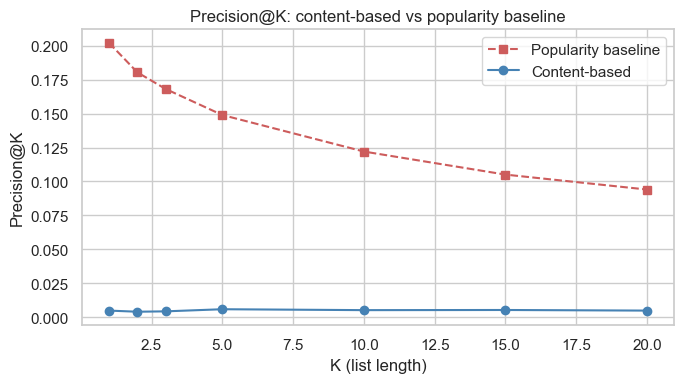

Figure saved.


In [6]:
ks = [1, 2, 3, 5, 10, 15, 20]

p_content_curve  = [precision_at_k_content(k=k) for k in ks]
p_popular_curve  = [precision_at_k_popular(k=k) for k in ks]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, p_popular_curve, marker="s", label="Popularity baseline", color="indianred",  linestyle="--")
ax.plot(ks, p_content_curve, marker="o", label="Content-based",       color="steelblue")
ax.set_xlabel("K (list length)")
ax.set_ylabel("Precision@K")
ax.set_title("Precision@K: content-based vs popularity baseline")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/content_vs_baseline_precision.png", dpi=150)
plt.show()
print("Figure saved.")

## 7. Understanding the limits

Content-based filtering has two well-known weaknesses worth knowing:

**1. Over-specialization** — the model only recommends movies similar to what the
user already likes. If someone enjoyed a lot of Action films, it will keep
suggesting Action — it will never surface a great Drama they might love.

**2. Shallow features** — we're only using genres. Two movies tagged `Drama` can be
completely different in tone, style, and quality. Richer features (cast, director,
plot keywords, decade) would improve this significantly.

These are the motivations for the next stage: **collaborative filtering**, which
doesn't use item features at all — it finds users with similar taste to you and
recommends what they liked.

In [7]:
# Show a concrete example of over-specialization:
# compare two users' profiles to see how different their recommendations are
user_ids = train["userId"].unique()[:2]

for uid in user_ids:
    profile = build_user_profile(uid)
    if profile is None:
        continue
    top_genres = pd.Series(profile, index=mlb.classes_).sort_values(ascending=False).head(3)
    recs = recommend_content(uid, n=5)
    print(f"\nUser {uid}  |  Top genres: {dict(top_genres.round(2))}")
    if recs is not None:
        print(recs[["title", "genres", "similarity"]].to_string(index=False))


User 509  |  Top genres: {'Comedy': np.float64(0.47), 'Adventure': np.float64(0.44), 'Drama': np.float64(0.34)}
                                             title                                              genres  similarity
   Ernest & Célestine (Ernest et Célestine) (2012)   Adventure|Animation|Children|Comedy|Drama|Romance       0.872
                                 Inside Out (2015)   Adventure|Animation|Children|Comedy|Drama|Fantasy       0.866
     Puss in Boots (Nagagutsu o haita neko) (1969) Adventure|Animation|Children|Comedy|Fantasy|Romance       0.848
                            Gnomeo & Juliet (2011) Adventure|Animation|Children|Comedy|Fantasy|Romance       0.848
Porco Rosso (Crimson Pig) (Kurenai no buta) (1992)          Adventure|Animation|Comedy|Fantasy|Romance       0.813

User 326  |  Top genres: {'Drama': np.float64(0.82), 'Thriller': np.float64(0.39), 'Crime': np.float64(0.32)}
                                                                      title           

## Summary

| Model | Precision@10 |
|---|---|
| Popularity baseline (Stage 2) | 0.1220 |
| Content-based (this stage) | *see cell output above* |

**What we built:**
- Binary genre feature vectors for every movie (`MultiLabelBinarizer`)
- Per-user taste profiles averaged from their liked movies
- Cosine similarity scoring to rank unseen movies

**Limitations identified:**
- Over-specialization: users stay in their genre bubble
- Genres alone are a crude signal — two dramas can be very different

**Next stage:** `04_collaborative_filtering.ipynb` — SVD-based matrix
factorization, which learns latent user *and* item representations entirely
from the rating patterns, with no item features needed.